In [1]:
from src import clustering, graph_utils, plotting
import spatialdata as sd
import os 
sdata = sd.read_zarr("zarr/debug_dataset.zarr")
adata = sdata.tables["table"]

/home/ktang/anaconda3/envs/single_cell_p311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/ktang/anaconda3/envs/single_cell_p311/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


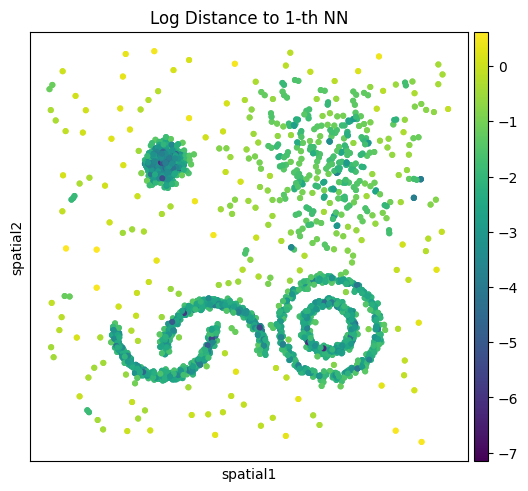

In [2]:
K = 1
graph_utils.get_distances(adata, k=1, log=True)
plotting.plot_knn_distance(adata, k=1)

In [3]:
results = clustering.fit_gmm(adata, distance_key="1_nn_distance", k_range=range(1,10))
# Some functionality missing like multiple inits

Fitted GMM with k=1
Fitted GMM with k=2
Fitted GMM with k=3
Fitted GMM with k=4
Fitted GMM with k=5
Fitted GMM with k=6
Fitted GMM with k=7
Fitted GMM with k=8
Fitted GMM with k=9


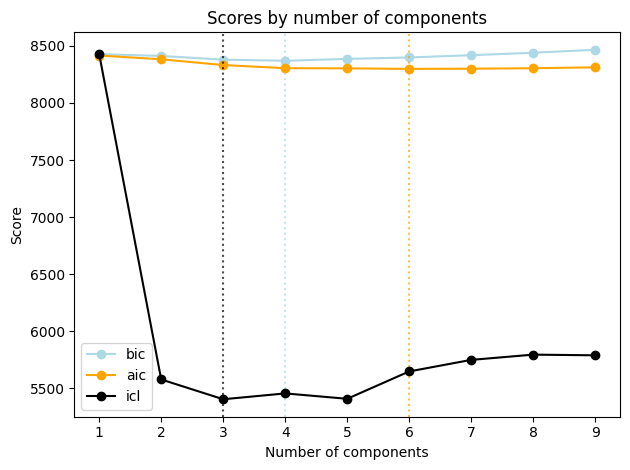

In [4]:
plotting.plot_scores(results)

In [5]:
best_model_icl = clustering.choose_component(results, criterion="icl", delta_bic_threshold=10.0)
best_model_bic = clustering.choose_component(results, criterion="bic", delta_bic_threshold=10.0)

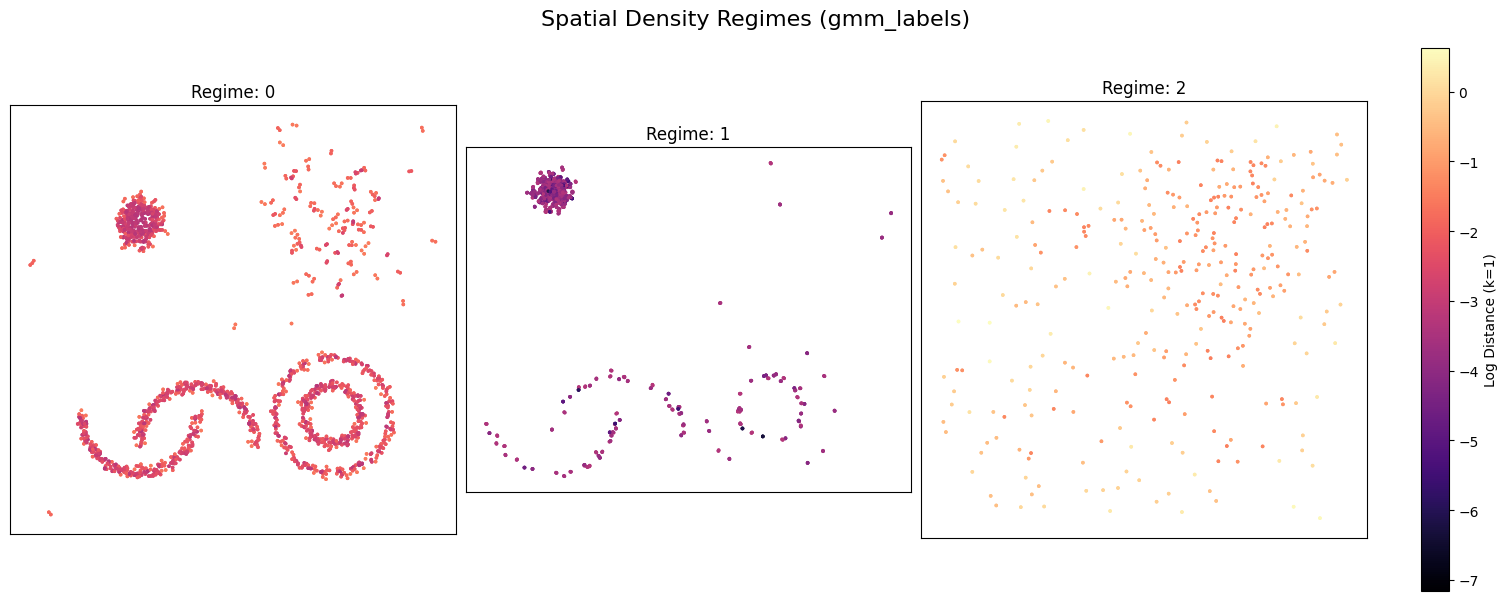

In [6]:
adata.obs["gmm_labels"] = best_model_icl["labels"]
adata.obs["gmm_labels"] = adata.obs["gmm_labels"].astype("category") 
plotting.plot_knn_by_regime(
    adata, 
    labels_key="gmm_labels", 
    k=1,             # Use k=1 distances
    size=10,         # Adjust dot size based on your data density
    cmap="magma",    # 'magma' is often good for density (dark = dense, bright = sparse)
    figsize=(15, 6)  # Force a specific figure size if the auto-calc isn't perfect
)

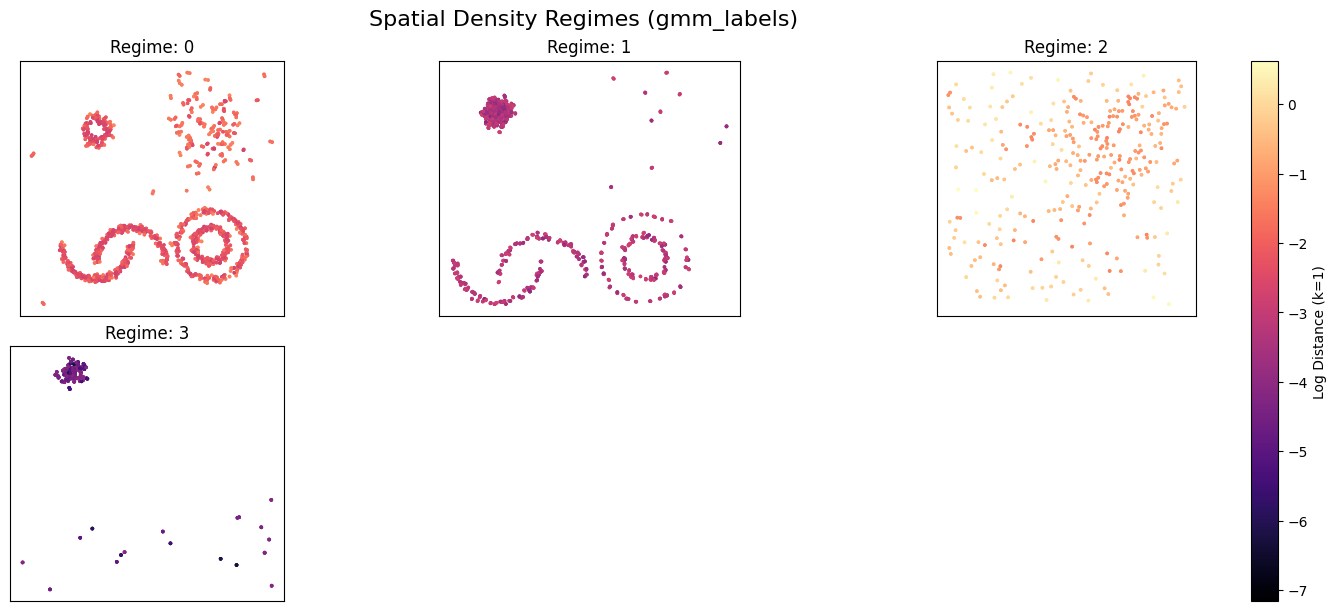

In [7]:
adata.obs["gmm_labels"] = best_model_bic["labels"]
adata.obs["gmm_labels"] = adata.obs["gmm_labels"].astype("category") 
plotting.plot_knn_by_regime(
    adata, 
    labels_key="gmm_labels", 
    k=1,             # Use k=1 distances
    size=10,         # Adjust dot size based on your data density
    cmap="magma",    # 'magma' is often good for density (dark = dense, bright = sparse)
    figsize=(15, 6)  # Force a specific figure size if the auto-calc isn't perfect
)

In [8]:
graph_utils.get_neighbors(adata, type="delaunay", gmm_labels="gmm_labels")

In [9]:
graph_utils.prune_graph(adata, type="percentile", percentile=95)

In [10]:
graph_utils.set_seeds(adata, "1_nn_distance", spatial_connectivity_key="spatial_connectivities_pruned")

In [11]:
for flavor in ["watershed", "leiden", "kmeans", "dbscan"]:
    clustering.cluster_domains(adata, spatial_connectivity_key="spatial_connectivities_pruned", flavor=flavor, distances_key="1_nn_distance")

/home/ktang/anaconda3/envs/single_cell_p311/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


Saved plot to niches.png


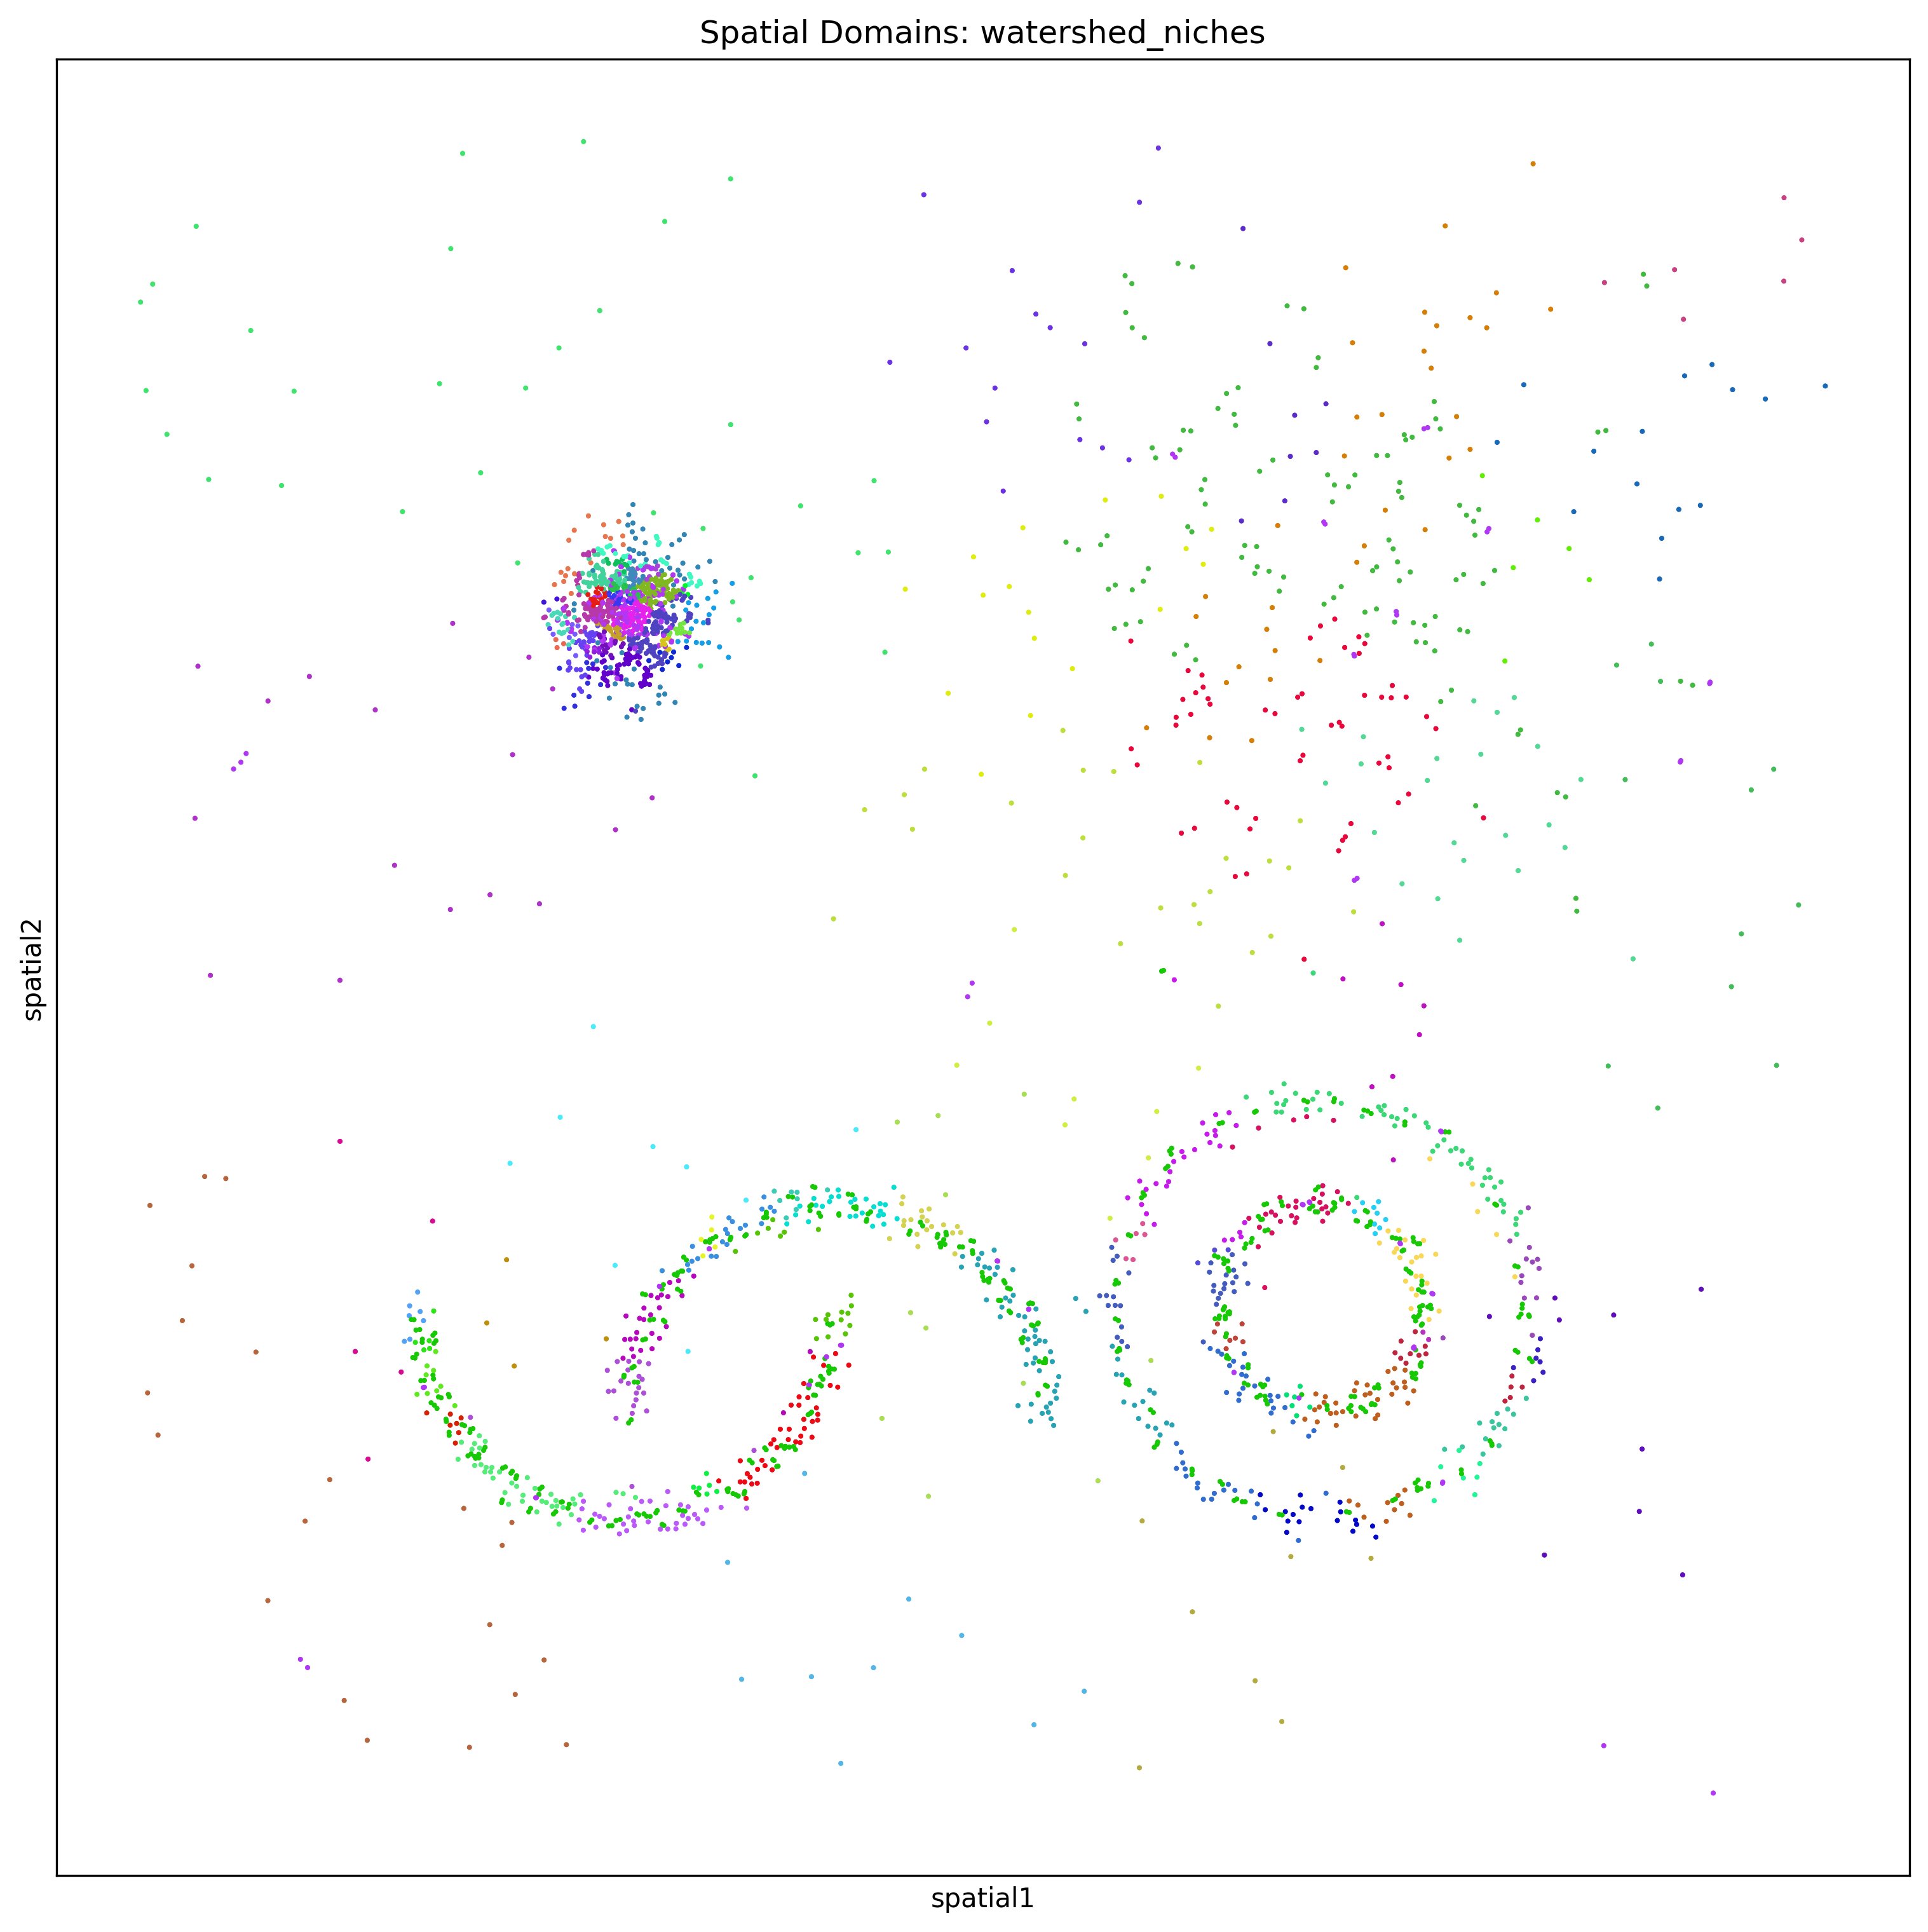

In [12]:
plotting.plot_niches(sdata, niche_key="watershed_niches", size=3, output_path="niches.png")